## __Tópicos avanzados en Inteligencia Artificial 1 - MIA__


__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

**Asunto**: Anomaly detection (AutoEncoder - keras, tensorflow) - Credit Card Fraud Detection

*****

## Librerias

In [45]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from numpy import linspace, mean, argmin
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Keras - tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

## Funciones personalizadas

In [3]:
def plot_history(history, width=12, height=6):
  """
  DESCRIPTION:
    History performance of the keras model
  
  INPUT:
    @param history: history of performance of fitted model
    @type history: tensorflow.python.keras.callbacks.History

  OUTPUT:
    A graphic
  """

  ## Metrics keys stored in tensorflow object
  keys = list(history.history.keys())

  ## Number of epoch used for fit the model
  epoch = range(1, len(history.epoch) +1)

  ## Check if validation set was used.
  withValidation = False
  for key in keys:
    if 'val' in key:
      withValidation = True

  ## Number of metrics 
  nMetrics = len(keys)
  if withValidation:
    nMetrics = nMetrics//2

  ## Plot-space instance
  plt.figure(figsize=(width, height))

  for i in range(nMetrics):
    plt.subplot(nMetrics, 1, i+1)

    ## Plot (train) metric value
    labelMetric = keys[i]
    metric = history.history[keys[i]]
    plt.plot(epoch, metric, 'o-', label=labelMetric)

    if withValidation:
      ## Plot (validation) metric value
      labelMetricVal = keys[i+nMetrics]
      metricVal = history.history[keys[i+nMetrics]]
      plt.plot(epoch, metricVal, 'o-', label=labelMetricVal)

    plt.xlim(epoch[0], epoch[-1])
    plt.legend()
    plt.grid()

  plt.xlabel('Epoch')
  plt.show()

## Dataset

<center>
    <img src=https://www.xenonstack.com/hs-fs/hubfs/xenonstack-credit-card-fraud-detection.png?width=1920&height=1080&name=xenonstack-credit-card-fraud-detection.png width=800>
</center>

El conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 en usuarios europeos.
Este conjunto de datos presenta transacciones que ocurrieron en dos días, donde tiene diagnosticado 492 casos fraudes de 284.807 transacciones. El conjunto de datos está muy desequilibrado, la clase positiva (fraudes) representa el 0,172% de todas las transacciones.

* La data y detalles está completamente disponible en [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://github.com/adoc-box/Datasets/raw/main/creditcard.zip)
* Descomprime el archivo __creditcard.zip__. Luego, dejar el archivo __'creditcard.csv__ junto con el script.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

In [4]:
dataset_name = 'creditcard.csv'

## Solo para Linux y MacOS
if os.name == 'posix':
    if not os.path.exists("creditcard.zip"):
        ## Download files

        !wget https://github.com/adoc-box/Datasets/raw/main/creditcard.zip

        ## un-compress joined zip file
        !unzip creditcard.zip
        
    else:
        if os.path.exists(dataset_name):
            !rm creditcard.csv
        !unzip creditcard.zip
        
else:
    print('Seguir las instrucciones para usuarios de Windows mencionado arriba.')

Seguir las instrucciones para usuarios de Windows mencionado arriba.


In [5]:
## Load data
data = read_csv('creditcard.csv')

print("No. of unique labels ", len(data['Class'].unique()))
print("Label values ",data.Class.unique())
# 0 is for normal credit card transaction
# 1 is for fraudulent credit card transaction

print('-------')
print("Break down of the Normal and Fraud Transactions")
print( data['Class'].value_counts(sort = True), end=2*'\n' )

data.head()

No. of unique labels  2
Label values  [0 1]
-------
Break down of the Normal and Fraud Transactions
0    284315
1       492
Name: Class, dtype: int64



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


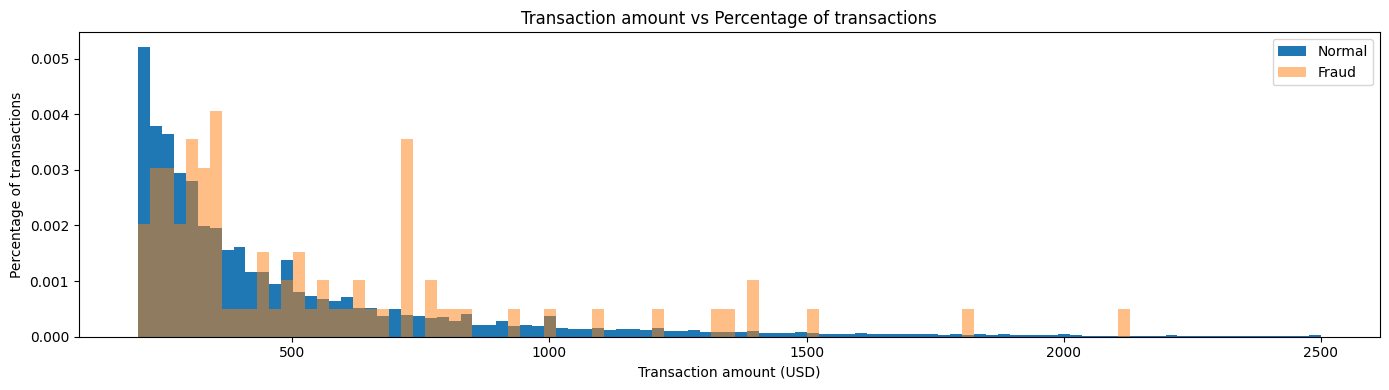

In [6]:
## Data splitting: the normal and fradulent transactions in separate dataframe
normal_data = data.query("Class == 0")
fraud_data = data.query("Class == 1")

## Visualize transaction amounts for normal and fraudulent transactions
bins = linspace(200, 2500, 100)
plt.figure(figsize=(14, 4))
plt.hist(normal_data.Amount, bins=bins, alpha=1, density=True, label='Normal')
plt.hist(fraud_data.Amount, bins=bins, alpha=0.5, density=True, label='Fraud')
plt.legend(loc='upper right')
plt.title("Transaction amount vs Percentage of transactions")
plt.xlabel("Transaction amount (USD)"); plt.ylabel("Percentage of transactions");
plt.tight_layout()
plt.show()

In [7]:
data.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Data pre-processing

In [23]:
## predictors and labels assigments
X, Y = data.drop(columns=['Time', 'Class']), data['Class']

## Train, validate and test set
X_trainVal, X_test, y_trainVal, y_test = train_test_split(X, Y, stratify=Y, 
                                                          test_size=0.2, 
                                                          random_state=84)

X_train, X_val, y_train, y_val = train_test_split(X_trainVal, y_trainVal, 
                                                  stratify=y_trainVal, 
                                                  test_size=0.2, 
                                                  random_state=84)

print('Train (Shape) - X: {}, y: {}'.format(X_train.shape, y_train.shape))
print('Val (Shape) - X: {}, y: {}'.format(X_val.shape, y_val.shape))
print('Test (Shape) - X: {}, y: {}\n'.format(X_test.shape, y_test.shape))


## Extract normal (no fraud) data for training and validate
X_train_normal = X_train[ y_train.values == 0 ]
X_val_normal = X_val[ y_val.values == 0 ]
X_trainVal_normal = X_trainVal[ y_trainVal.values == 0 ]

print('Train (Shape) Normal cases - X: {}'.format(X_train_normal.shape))
print('Val (Shape) Normal cases - X: {}'.format(X_val_normal.shape))
print('Train+Val (Shape) Normal cases - X: {}'.format(X_trainVal_normal.shape))



## Data normalization
scaler = MinMaxScaler().fit(X_train_normal)
X_train_normal = scaler.transform(X_train_normal)
X_val_normal = scaler.transform(X_val_normal)
X_trainVal_normal = scaler.transform(X_trainVal_normal)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Train (Shape) - X: (182276, 29), y: (182276,)
Val (Shape) - X: (45569, 29), y: (45569,)
Test (Shape) - X: (56962, 29), y: (56962,)

Train (Shape) Normal cases - X: (181961, 29)
Val (Shape) Normal cases - X: (45490, 29)
Train+Val (Shape) Normal cases - X: (227451, 29)


## Model building

<center>

![https://towardsdatascience.com/anomaly-detection-using-autoencoders-5b032178a1ea](https://miro.medium.com/max/700/1*ce89U6z-MhgGRln9VRAMxQ.png)

</center>

#### Model A

In [ ]:
## Tiempo aprox. de ejecución: 4 minutos (GPU) - 

## Input shape
INPUT_LEN = X_train_normal.shape[1]
print('Input length: {}\n'.format(INPUT_LEN))

## Model instance
autoencoder = Sequential(name='AutoEncoder')
autoencoder.add(layers.Input(shape=(INPUT_LEN, ), name='Input'))

#### Encoder
autoencoder.add(layers.Dense(units=14, 
                             activation='tanh',
                             name='Enc_Dense_01'))
autoencoder.add(layers.Dense(units=7, 
                             activation='relu',
                             name='Enc_Dense_02'))
autoencoder.add(layers.Dense(units=4, 
                             activation='relu',
                             name='Enc_output'))

#### Decoder
autoencoder.add(layers.Dense(units=7, 
                             activation='relu',
                             name='Dec_Dense_01'))
autoencoder.add(layers.Dense(units=14, 
                             activation='relu',
                             name='Dec_Dense_02'))
autoencoder.add(layers.Dense(units=INPUT_LEN, 
                             activation='tanh',
                             name='Dec_output'))


## Compiler setting
autoencoder.compile(loss='mse', 
                    metrics=['mae'], 
                    optimizer='adam') 

## Summary
autoencoder.summary()

Input length: 29

Model: "AutoEncoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Enc_Dense_01 (Dense)        (None, 14)                420       
                                                                 
 Enc_Dense_02 (Dense)        (None, 7)                 105       
                                                                 
 Enc_output (Dense)          (None, 4)                 32        
                                                                 
 Dec_Dense_01 (Dense)        (None, 7)                 35        
                                                                 
 Dec_Dense_02 (Dense)        (None, 14)                112       
                                                                 
 Dec_output (Dense)          (None, 29)                435       
                                                                 
Total params: 1,139
Trainable params:

In [25]:
## Model fitting
start = time()
history = autoencoder.fit(x=X_train_normal, y=X_train_normal,
                          epochs=20,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(X_val_normal, X_val_normal)
                          )

timeUp = time()
print('Time spent[s]: {:.2f}'.format(timeUp -start))

Epoch 1/20
2844/2844 [==============================] - 15s 5ms/step - loss: 0.0080 - mae: 0.0415 - val_loss: 0.0024 - val_mae: 0.0308
Epoch 2/20
2844/2844 [==============================] - 11s 4ms/step - loss: 0.0023 - mae: 0.0310 - val_loss: 0.0023 - val_mae: 0.0312
Epoch 3/20
2844/2844 [==============================] - 13s 5ms/step - loss: 0.0022 - mae: 0.0302 - val_loss: 0.0022 - val_mae: 0.0294
Epoch 4/20
2844/2844 [==============================] - 12s 4ms/step - loss: 0.0022 - mae: 0.0291 - val_loss: 0.0022 - val_mae: 0.0291
Epoch 5/20
2844/2844 [==============================] - 12s 4ms/step - loss: 0.0021 - mae: 0.0289 - val_loss: 0.0022 - val_mae: 0.0289
Epoch 6/20
2844/2844 [==============================] - 12s 4ms/step - loss: 0.0021 - mae: 0.0287 - val_loss: 0.0022 - val_mae: 0.0287
Epoch 7/20
2844/2844 [==============================] - 12s 4ms/step - loss: 0.0021 - mae: 0.0286 - val_loss: 0.0021 - val_mae: 0.0285
Epoch 8/20
2844/2844 [==============================] -

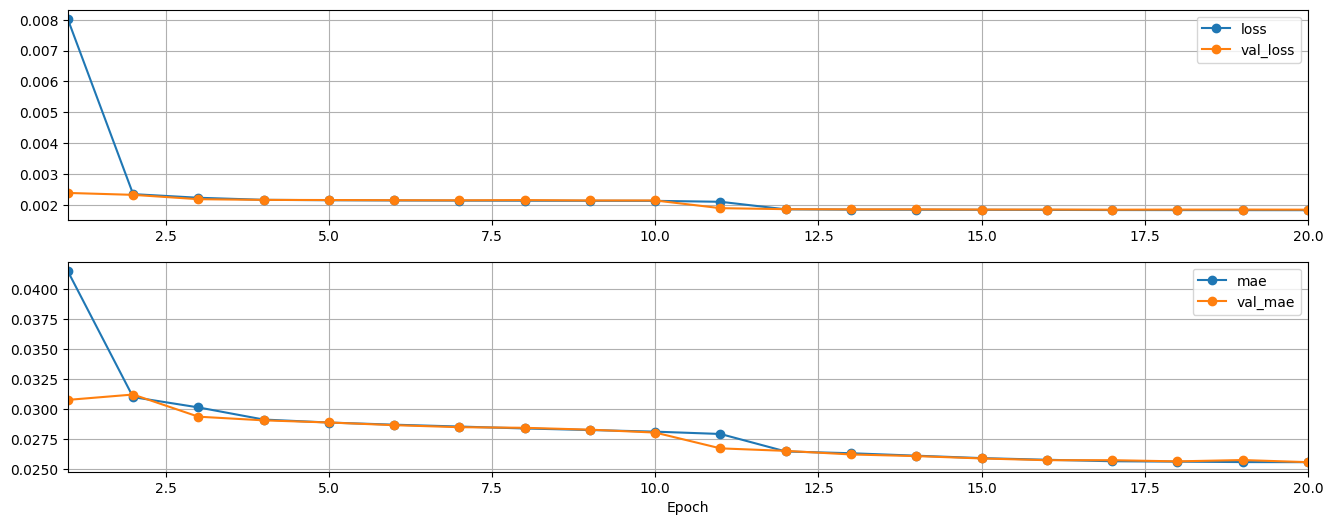

In [26]:
## Display performance
plot_history(history, width=16)

In [ ]:
## Searching for the best epoch
id_min = argmin(history.history['val_loss'])
print('MSE - Validation: {} - Error: {}'.format(id_min+1, history.history['val_loss'][id_min]))

id_min = argmin(history.history['val_mae'])
print('MAE - Validation: {} - Error: {}'.format(id_min+1, history.history['val_mae'][id_min]))

MSE - Validation: 17 - Error: 0.0018439689883962274
MAE - Validation: 20 - Error: 0.025607004761695862


#### Model B

In [ ]:
## Tiempo aprox. de ejecución: 4.40 min (GPU)
## Input shape
INPUT_LEN = X_train_normal.shape[1]
print('Input length: {}\n'.format(INPUT_LEN))

## Model instance
autoencoder = Sequential(name='AutoEncoder')
autoencoder.add(layers.Input(shape=(INPUT_LEN, ), name='Input'))

#### Encoder
autoencoder.add(layers.Dense(units=20, 
                             activation='tanh',
                             name='Enc_Dense_01'))
autoencoder.add(layers.Dense(units=15, 
                             activation='relu',
                             name='Enc_Dense_02'))
autoencoder.add(layers.Dense(units=10, 
                             activation='relu',
                             name='Enc_Dense_03'))
autoencoder.add(layers.Dense(units=5, 
                             activation='relu',
                             name='Enc_output'))

#### Decoder
autoencoder.add(layers.Dense(units=10, 
                             activation='relu',
                             name='Dec_Dense_01'))
autoencoder.add(layers.Dense(units=15, 
                             activation='relu',
                             name='Dec_Dense_02'))
autoencoder.add(layers.Dense(units=20, 
                             activation='relu',
                             name='Dec_Dense_03'))
autoencoder.add(layers.Dense(units=INPUT_LEN, 
                             activation='tanh',
                             name='Dec_output'))


## Compiler setting
autoencoder.compile(loss='mse', 
                    metrics=['mae'], 
                    optimizer='adam') 

## Summary
autoencoder.summary()

Input length: 29

Model: "AutoEncoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Enc_Dense_01 (Dense)        (None, 20)                600       
                                                                 
 Enc_Dense_02 (Dense)        (None, 15)                315       
                                                                 
 Enc_Dense_03 (Dense)        (None, 10)                160       
                                                                 
 Enc_output (Dense)          (None, 5)                 55        
                                                                 
 Dec_Dense_01 (Dense)        (None, 10)                60        
                                                                 
 Dec_Dense_02 (Dense)        (None, 15)                165       
                                                                 
 Dec_Dense_03 (Dense)        (None, 2

In [41]:
## Model fitting
start = time()
history = autoencoder.fit(x=X_train_normal, y=X_train_normal,
                          epochs=20,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(X_val_normal, X_val_normal)
                          )

timeUp = time()
print('Time spent[s]: {:.2f}'.format(timeUp -start))

Epoch 1/20
2844/2844 [==============================] - 15s 5ms/step - loss: 0.0059 - mae: 0.0377 - val_loss: 0.0020 - val_mae: 0.0290
Epoch 2/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0019 - mae: 0.0282 - val_loss: 0.0019 - val_mae: 0.0283
Epoch 3/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0018 - mae: 0.0277 - val_loss: 0.0017 - val_mae: 0.0271
Epoch 4/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0016 - mae: 0.0257 - val_loss: 0.0016 - val_mae: 0.0249
Epoch 5/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0015 - mae: 0.0243 - val_loss: 0.0015 - val_mae: 0.0240
Epoch 6/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0015 - mae: 0.0238 - val_loss: 0.0015 - val_mae: 0.0236
Epoch 7/20
2844/2844 [==============================] - 14s 5ms/step - loss: 0.0015 - mae: 0.0235 - val_loss: 0.0015 - val_mae: 0.0234
Epoch 8/20
2844/2844 [==============================] -

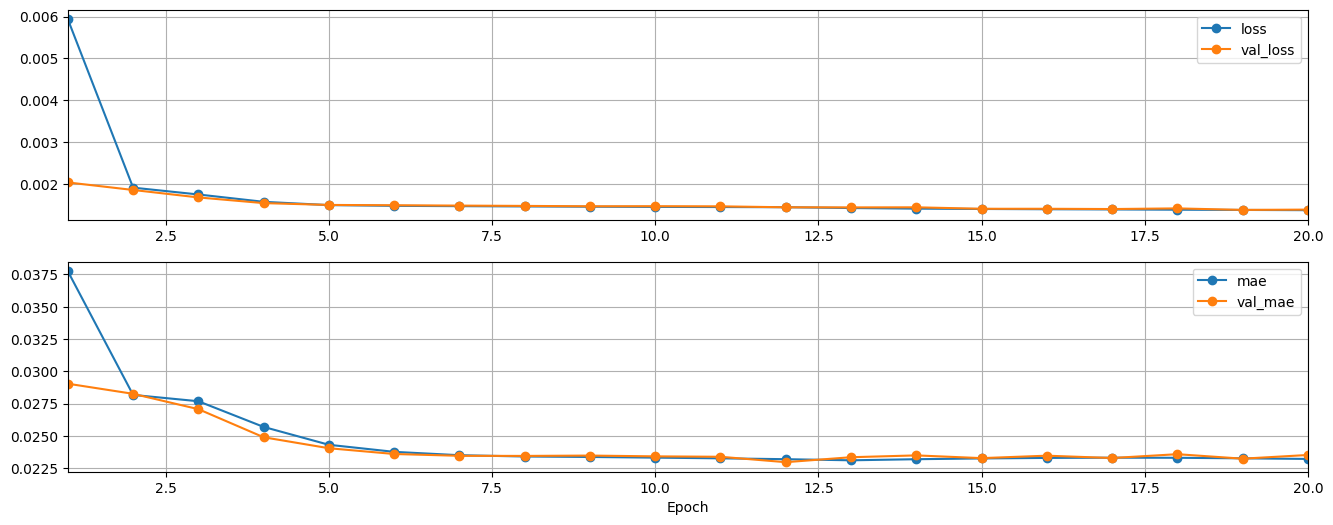

MSE - Validation: 19 - Error: 0.0013916210737079382
MAE - Validation: 12 - Error: 0.02295389585196972


In [42]:
## Display performance
plot_history(history, width=16)

## Searching best epochs
id_min = argmin(history.history['val_loss'])
print('MSE - Validation: {} - Error: {}'.format(id_min+1, history.history['val_loss'][id_min]))

id_min = argmin(history.history['val_mae'])
print('MAE - Validation: {} - Error: {}'.format(id_min+1, history.history['val_mae'][id_min]))

## Best model

In [ ]:
## Tiempo aprox. de ejecución: 4.50 min (GPU)
## Input shape
INPUT_LEN = X_train_normal.shape[1]
print('Input length: {}\n'.format(INPUT_LEN))

## Model instance
autoencoder = Sequential(name='AutoEncoder')
autoencoder.add(layers.Input(shape=(INPUT_LEN, ), name='Input'))

#### Encoder
autoencoder.add(layers.Dense(units=20, 
                             activation='tanh',
                             name='Enc_Dense_01'))
autoencoder.add(layers.Dense(units=15, 
                             activation='relu',
                             name='Enc_Dense_02'))
autoencoder.add(layers.Dense(units=10, 
                             activation='relu',
                             name='Enc_Dense_03'))
autoencoder.add(layers.Dense(units=5, 
                             activation='relu',
                             name='Enc_output'))

#### Decoder
autoencoder.add(layers.Dense(units=10, 
                             activation='relu',
                             name='Dec_Dense_01'))
autoencoder.add(layers.Dense(units=15, 
                             activation='relu',
                             name='Dec_Dense_02'))
autoencoder.add(layers.Dense(units=20, 
                             activation='relu',
                             name='Dec_Dense_03'))
autoencoder.add(layers.Dense(units=INPUT_LEN, 
                             activation='tanh',
                             name='Dec_output'))


## Compiler setting
autoencoder.compile(loss='mse', 
                    metrics=['mae'], 
                    optimizer='adam') 

## Model fitting
start = time()
history = autoencoder.fit(x=X_trainVal_normal, y=X_trainVal_normal,
                          epochs=19,
                          batch_size=64,
                          shuffle=True
                          )

timeUp = time()
print('Time spent[s]: {:.2f}'.format(timeUp -start))

Input length: 29

Epoch 1/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0068 - mae: 0.0392
Epoch 2/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0023 - mae: 0.0304
Epoch 3/19
3554/3554 [==============================] - 16s 4ms/step - loss: 0.0022 - mae: 0.0290
Epoch 4/19
3554/3554 [==============================] - 16s 4ms/step - loss: 0.0021 - mae: 0.0281
Epoch 5/19
3554/3554 [==============================] - 16s 4ms/step - loss: 0.0018 - mae: 0.0266
Epoch 6/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0018 - mae: 0.0263
Epoch 7/19
3554/3554 [==============================] - 14s 4ms/step - loss: 0.0017 - mae: 0.0261
Epoch 8/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0017 - mae: 0.0257
Epoch 9/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0016 - mae: 0.0254
Epoch 10/19
3554/3554 [==============================] - 15s 4ms/step - loss: 0.0016 - mae: 0.0252
E

In [44]:
## Compute predictions 
predictions = autoencoder.predict(X_test)

## Compute MSE 
MSE = mean( (predictions - X_test)**2, axis=1 )

## Estimation and true labels dataframe
MSE_df = DataFrame({'Reconstruction_error': MSE,
                    'True_class': y_test})
MSE_df

1781/1781 [==============================] - 3s 2ms/step


,Reconstruction_error,True_class
180305,0.001243,0
147279,0.002145,0
254854,0.001163,0
66368,0.001629,0
283535,0.000890,0
...,...,...
254524,0.001147,0
13527,0.000951,0
235447,0.000716,0
51554,0.001936,0


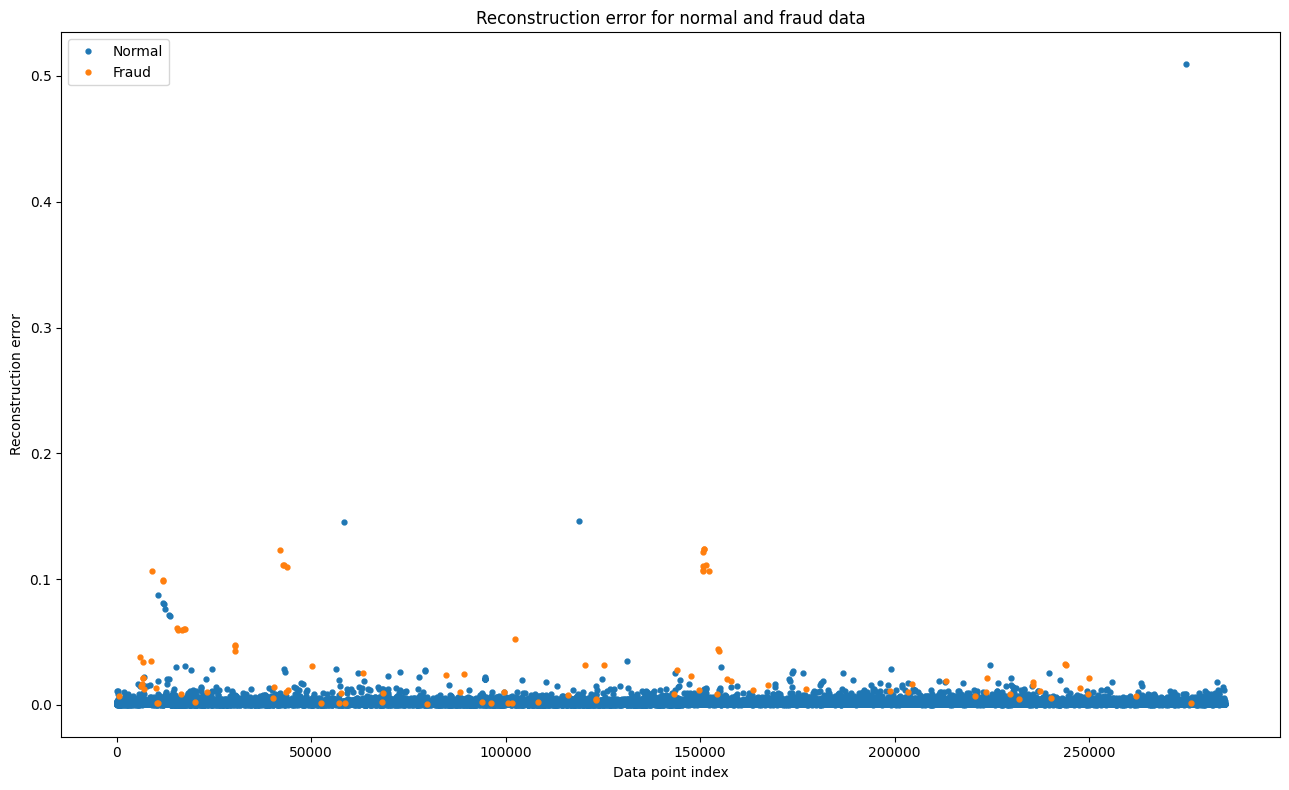

In [63]:
## Display reconstruction error by class (normal and fraud)
plt.figure(figsize=(13, 8))
for name, group in MSE_df.groupby('True_class'):
    plt.plot(group.index, group.Reconstruction_error, 
             marker='o', ms=3.5, linestyle='',
             label= "Fraud" if name == 1 else "Normal")
plt.legend()
plt.title("Reconstruction error for normal and fraud data")
plt.ylabel("Reconstruction error"); plt.xlabel("Data point index")
plt.tight_layout()
plt.show()

<center>
    <img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSnNx7KFk7EQMOVIPxyb7-HzOBgeUSNcPKHsA&usqp=CAU'>
</center>



<center>
    <img src=https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKx429Le1ASVshhg_Pr9iYlbnW_xosRO4Ce5mvFHDysNek26Wn8lsi_m7B8a04bpFty3k&usqp=CAU width=400>
</center>

In [51]:
## Anomaly threshold
anomaly_threshold = 0.0075

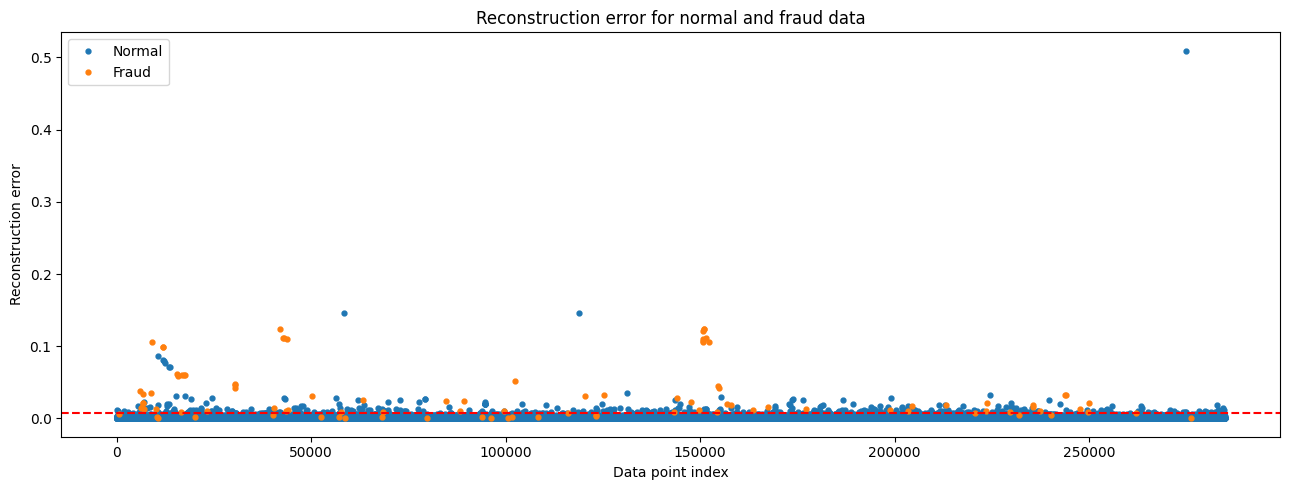

In [55]:
## Display reconstruction error by class (normal and fraud)
plt.figure(figsize=(13, 5))
for name, group in MSE_df.groupby('True_class'):
    plt.plot(group.index, group.Reconstruction_error, 
             marker='o', ms=3.5, linestyle='',
             label= "Fraud" if name == 1 else "Normal")
plt.axhline(anomaly_threshold, color='red', ls='--')
plt.legend()
plt.title("Reconstruction error for normal and fraud data")
plt.ylabel("Reconstruction error"); plt.xlabel("Data point index")
plt.tight_layout()
plt.show()

## Detection performance

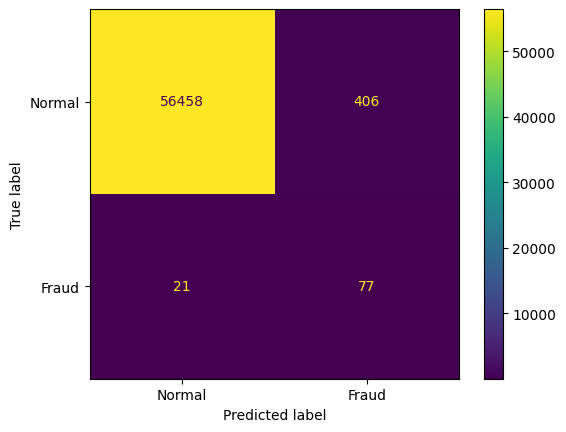

In [53]:
## Anomalies identification
anomalies = [1 if value >= anomaly_threshold else 0 for value in MSE ]

## Display confusion matrix
cm = confusion_matrix(y_pred=anomalies, y_true=y_test)
CM = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal","Fraud"])
CM.plot()
plt.show()

In [54]:
## Display classification report
print(classification_report(y_pred=anomalies, 
                            y_true=y_test, 
                            digits=2,
                            target_names=["Normal","Fraud"]) )

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.16      0.79      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.89      0.63     56962
weighted avg       1.00      0.99      0.99     56962

